In [2]:
!pip install imbalanced-learn

### Knižnice ###

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    f1_score,
    make_scorer,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

### Data ###

In [6]:
#Načítanie dát zo súboru
df = pd.read_csv("data.csv")

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

#Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (5455, 95)
Shape X_test: (1364, 95)


### Baseline RF ###

Baseline Random Forest
              precision    recall  f1-score   support

           0    0.97483   0.99773   0.98615      1320
           1    0.76923   0.22727   0.35088        44

    accuracy                        0.97287      1364
   macro avg    0.87203   0.61250   0.66851      1364
weighted avg    0.96820   0.97287   0.96565      1364


Confusion Matrix
[[1317    3]
 [  34   10]]


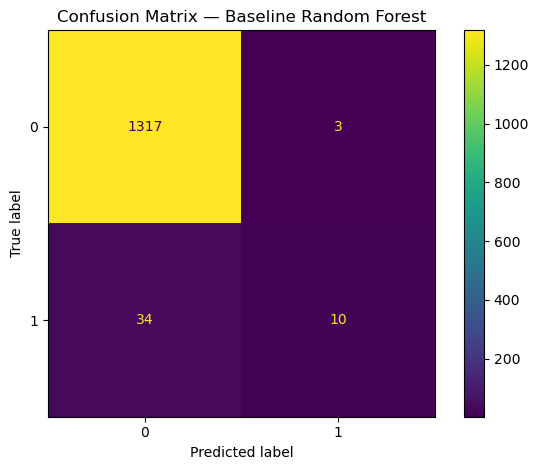

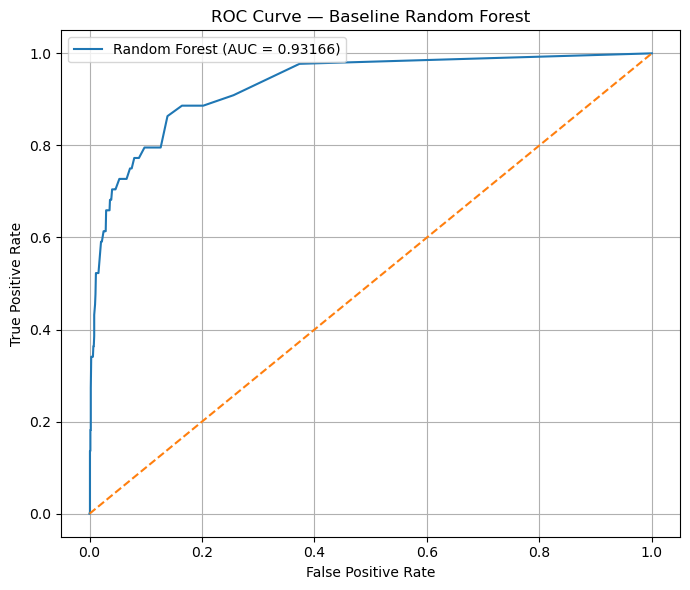

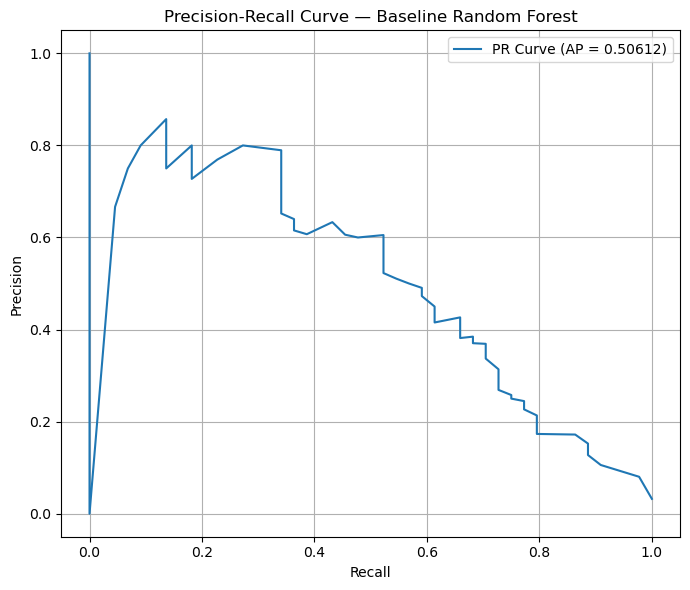

ROC AUC: 0.93166
PRC AUC (Average Precision): 0.50612


In [8]:
#Vytvorenie základného RF modelu s váhou pre nevyvážené triedy
rf1 = RandomForestClassifier()

rf1.fit(X_train, y_train)

y_pred1 = rf1.predict(X_test)
y_proba1 = rf1.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Baseline Random Forest")
print(classification_report(y_test, y_pred1, digits=5))

#Matica zámen
cm1 = confusion_matrix(y_test, y_pred1)
print("\nConfusion Matrix")
print(cm1)

ConfusionMatrixDisplay(cm1).plot()
plt.title("Confusion Matrix — Baseline Random Forest")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc1 = roc_auc_score(y_test, y_proba1)
fpr1, tpr1, _ = roc_curve(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(fpr1, tpr1, label=f"Random Forest (AUC = {roc_auc1:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions1, recalls1, _ = precision_recall_curve(y_test, y_proba1)
prc_auc1 = average_precision_score(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(recalls1, precisions1, label=f"PR Curve (AP = {prc_auc1:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Random Forest")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc1:.5f}")
print(f"PRC AUC (Average Precision): {prc_auc1:.5f}")

### Baseline RF + SMOTE ###

Baseline Random Forest + SMOTE
              precision    recall  f1-score   support

           0    0.98547   0.97652   0.98097      1320
           1    0.44643   0.56818   0.50000        44

    accuracy                        0.96334      1364
   macro avg    0.71595   0.77235   0.74049      1364
weighted avg    0.96809   0.96334   0.96546      1364


Confusion Matrix
[[1289   31]
 [  19   25]]


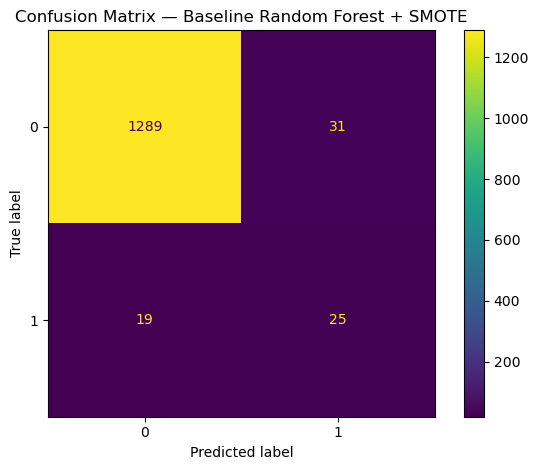

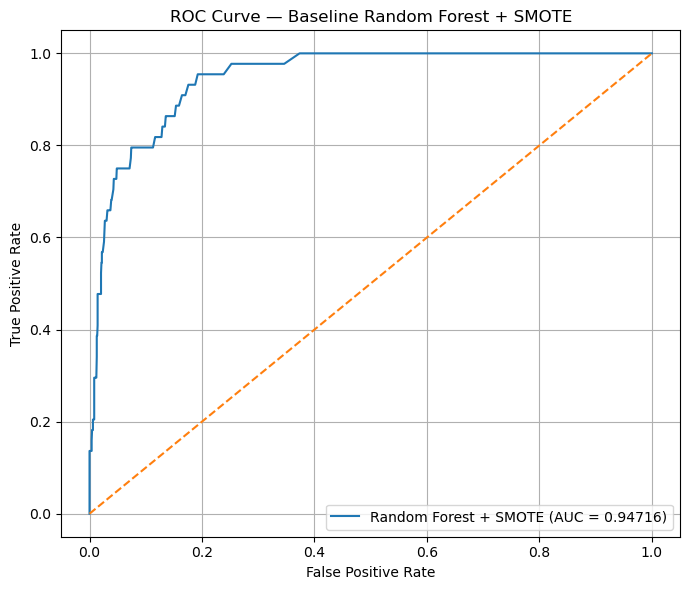

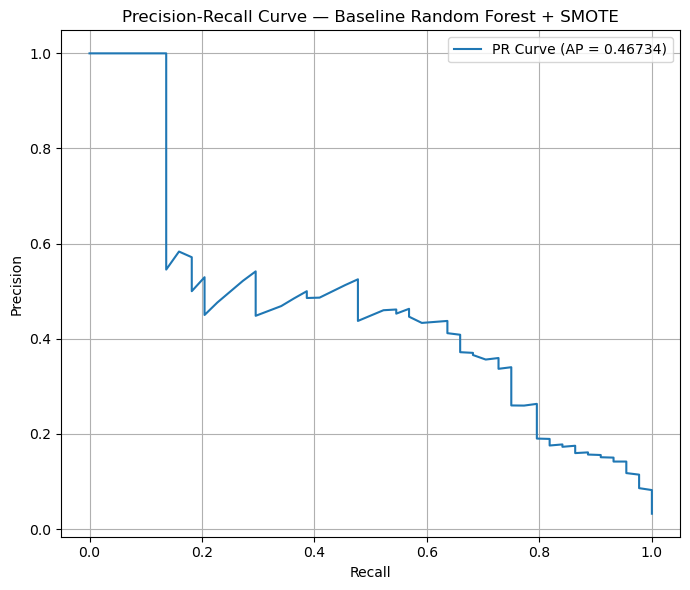

ROC AUC: 0.94716
PRC AUC (Average Precision): 0.46734


In [10]:
#Vytvorenie pipeline so SMOTE a RF modelom
baseline_smote_rf = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs=-1
    ))
])

#Trénovanie pipeline na trénovacích dátach
baseline_smote_rf.fit(X_train, y_train)

#Trénovanie pipeline na trénovacích dátach
y_pred2 = baseline_smote_rf.predict(X_test)

#Predikcia tried na testovacích dátach
y_proba2 = baseline_smote_rf.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Baseline Random Forest + SMOTE")
print(classification_report(y_test, y_pred2, digits=5))

#Matica zámen
cm2 = confusion_matrix(y_test, y_pred2)
print("\nConfusion Matrix")
print(cm2)

ConfusionMatrixDisplay(cm2).plot()
plt.title("Confusion Matrix — Baseline Random Forest + SMOTE")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc2 = roc_auc_score(y_test, y_proba2)
fpr2, tpr2, _ = roc_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(fpr2, tpr2, label=f"Random Forest + SMOTE (AUC = {roc_auc2:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Random Forest + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba2)
prc_auc2 = average_precision_score(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(recalls2, precisions2, label=f"PR Curve (AP = {prc_auc2:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Random Forest + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc2:.5f}")
print(f"PRC AUC (Average Precision): {prc_auc2:.5f}")

### Baseline RF + ADASYN ###

Baseline Random Forest + ADASYN
              precision    recall  f1-score   support

           0    0.98621   0.97500   0.98057      1320
           1    0.44068   0.59091   0.50485        44

    accuracy                        0.96261      1364
   macro avg    0.71344   0.78295   0.74271      1364
weighted avg    0.96861   0.96261   0.96523      1364


Confusion Matrix
[[1287   33]
 [  18   26]]


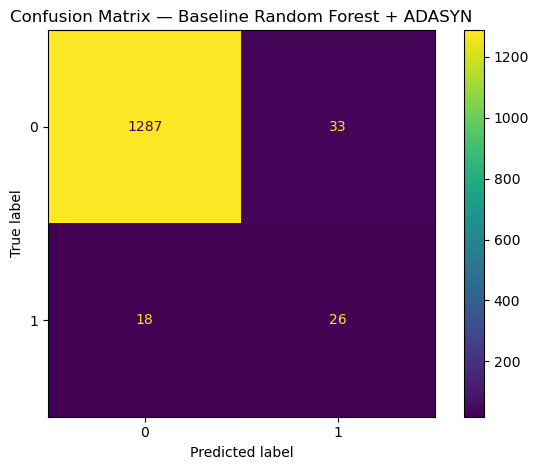

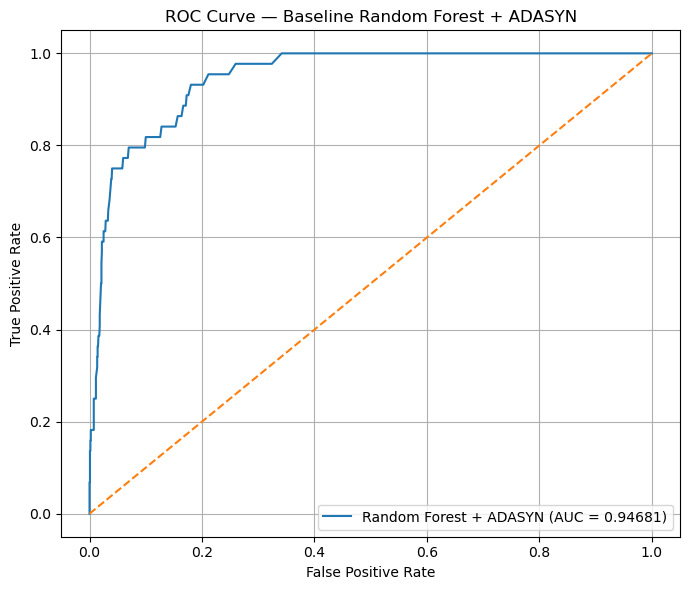

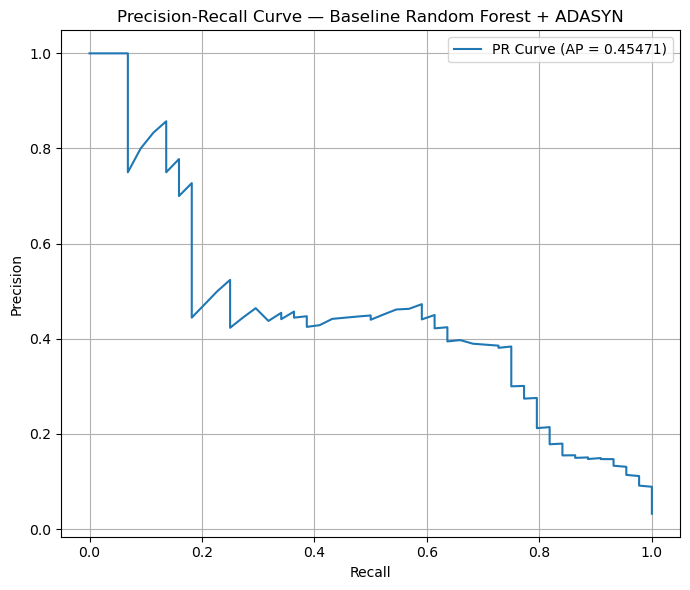

ROC AUC: 0.94681
PRC AUC (Average Precision): 0.45471


In [12]:
#Vytvorenie pipeline s ADASYN a RF modelom
baseline_adasyn_rf = ImbPipeline(steps=[
    ("adasyn", ADASYN(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs=-1
    ))
])

#Trénovanie modelu na trénovacích dátach
baseline_adasyn_rf.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred3 = baseline_adasyn_rf.predict(X_test)

# Predikcia pravdepodobnosti pre triedu 1
y_proba3 = baseline_adasyn_rf.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Baseline Random Forest + ADASYN")
print(classification_report(y_test, y_pred3, digits=5))

#Matica zámen
cm3 = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix")
print(cm3)

ConfusionMatrixDisplay(cm3).plot()
plt.title("Confusion Matrix — Baseline Random Forest + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc3 = roc_auc_score(y_test, y_proba3)
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(fpr3, tpr3, label=f"Random Forest + ADASYN (AUC = {roc_auc3:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Random Forest + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba3)
prc_auc3 = average_precision_score(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(recalls3, precisions3, label=f"PR Curve (AP = {prc_auc3:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline Random Forest + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc3:.5f}")
print(f"PRC AUC (Average Precision): {prc_auc3:.5f}")

### RF + UnderSampling + SMOTE + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best params:
{'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'smote__k_neighbors': 3, 'smote__sampling_strategy': 0.25, 'under__sampling_strategy': 0.08}
F1-score (CV): 0.4724
Best threshold: 0.6683

Classification Report (Random Forest + UnderSampling + SMOTE + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0    0.98263   0.98561   0.98411      1320
           1    0.52500   0.47727   0.50000        44

    accuracy                        0.96921      1364
   macro avg    0.75381   0.73144   0.74206      1364
weighted avg    0.96787   0.96921   0.96850      1364


Confusion Matrix
[[1301   19]
 [  23   21]]


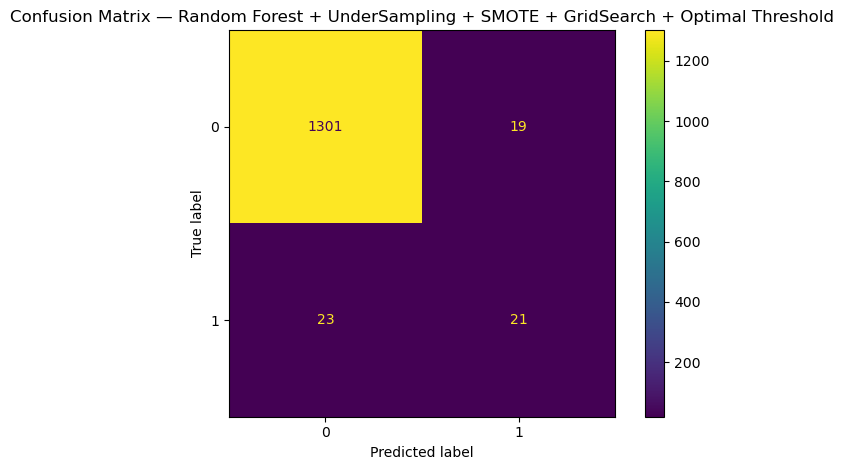

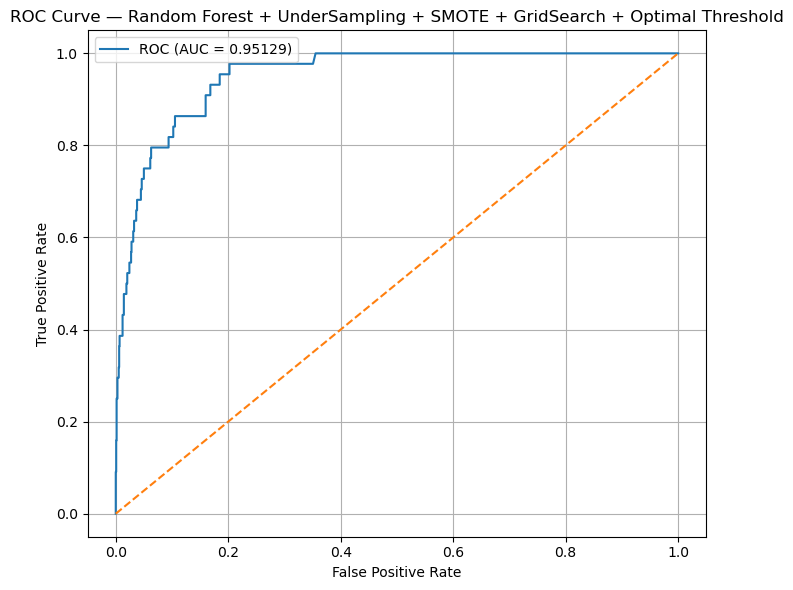

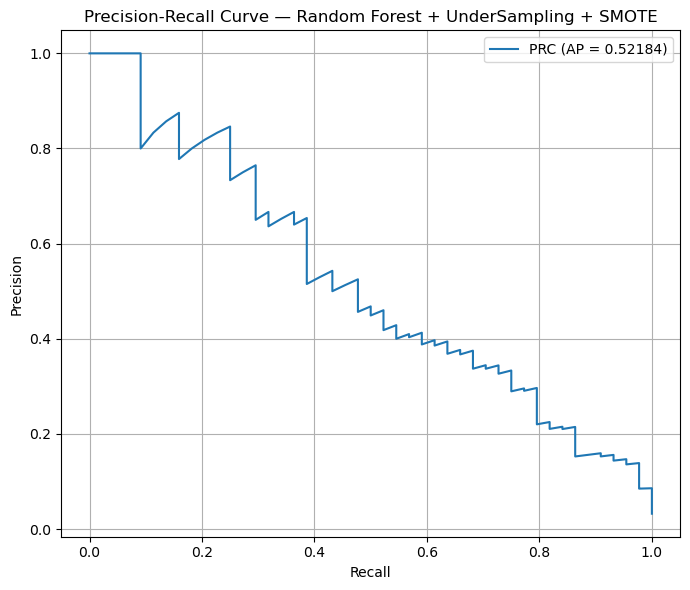

ROC AUC: 0.95129
PRC AUC: 0.52184


In [16]:
#Vytvorenie pipeline s undersamplingom, SMOTE a KNN modelom
pipe = ImbPipeline(steps=[
    ("under", RandomUnderSampler(random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

#Definovanie rozsahu hyperparametrov pre GridSearch
param_grid = {
    "under__sampling_strategy": [0.05, 0.08],     
    "smote__sampling_strategy": [0.25, 0.30],     
    "smote__k_neighbors": [3],                    

    "model__n_estimators": [100, 200],            
    "model__max_depth": [10, 20, None],           
    "model__min_samples_split": [2, 5],           
    "model__min_samples_leaf": [1, 2],            
    "model__max_features": ["sqrt", "log2"]      
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definovanie hodnotiacej metriky F1-score
scorer = make_scorer(f1_score, pos_label=1)

#Nastavenie GridSearchCV pre hľadanie najlepších parametrov
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

#Spustenie trénovania a hľadania najlepšieho modelu
grid_search.fit(X_train, y_train)

#Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

#Uloženie najlepšieho modelu
best_model4 = grid_search.best_estimator_

#Výpočet pravdepodobností pre triedu 1
y_proba4 = best_model4.predict_proba(X_test)[:, 1]

precisions4, recalls4, thresholds4 = precision_recall_curve(y_test, y_proba4)

#Výpočet F1-score pre rôzne prahy
f1_scores4 = 2 * (precisions4[:-1] * recalls4[:-1]) / (
    precisions4[:-1] + recalls4[:-1] + 1e-10
)

#Výber prahu s najvyšším F1-score
best_threshold4 = thresholds4[np.argmax(f1_scores4)]
print(f"Best threshold: {best_threshold4:.4f}")

#Predikcia tried podľa optimálneho prahu
y_pred4 = (y_proba4 >= best_threshold4).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (Random Forest + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred4, digits=5))

roc_auc4 = roc_auc_score(y_test, y_proba4)
prc_auc4 = average_precision_score(y_test, y_proba4)

#Matica zámen
cm4 = confusion_matrix(y_test, y_pred4)
print("\nConfusion Matrix")
print(cm4)

ConfusionMatrixDisplay(cm4).plot()
plt.title("Confusion Matrix — Random Forest + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
fpr4, tpr4, _ = roc_curve(y_test, y_proba4)

plt.figure(figsize=(7, 6))
plt.plot(fpr4, tpr4, label=f"ROC (AUC = {roc_auc4:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
plt.figure(figsize=(7, 6))
plt.plot(recalls4, precisions4, label=f"PRC (AP = {prc_auc4:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest + UnderSampling + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc4:.5f}")
print(f"PRC AUC: {prc_auc4:.5f}")

### RF + UnderSampling + ADASYN + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best params:
{'adasyn__n_neighbors': 3, 'adasyn__sampling_strategy': 0.25, 'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'under__sampling_strategy': 0.05}
F1-score (CV): 0.4753
Best threshold: 0.5734
Best F1 from PR curve: 0.5495

Classification Report (Random Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0    0.98557   0.98333   0.98445      1320
           1    0.53191   0.56818   0.54945        44

    accuracy                        0.96994      1364
   macro avg    0.75874   0.77576   0.76695      1364
weighted avg    0.97094   0.96994   0.97042      1364


Confusion Matrix
[[1298   22]
 [  19   25]]


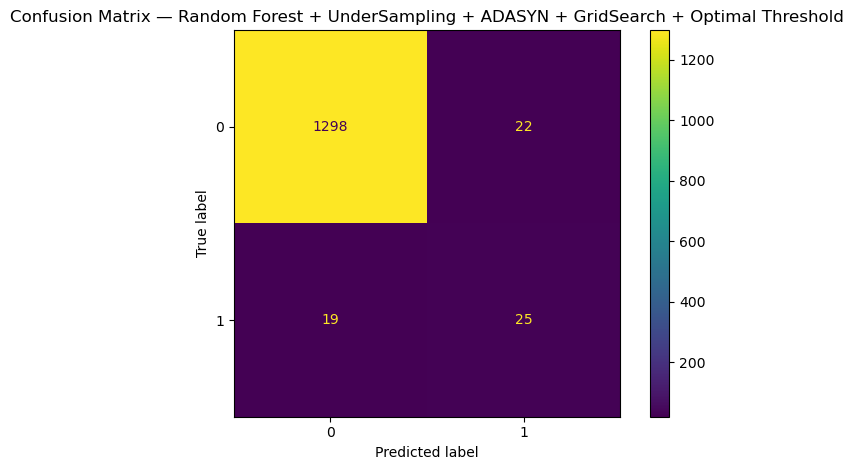

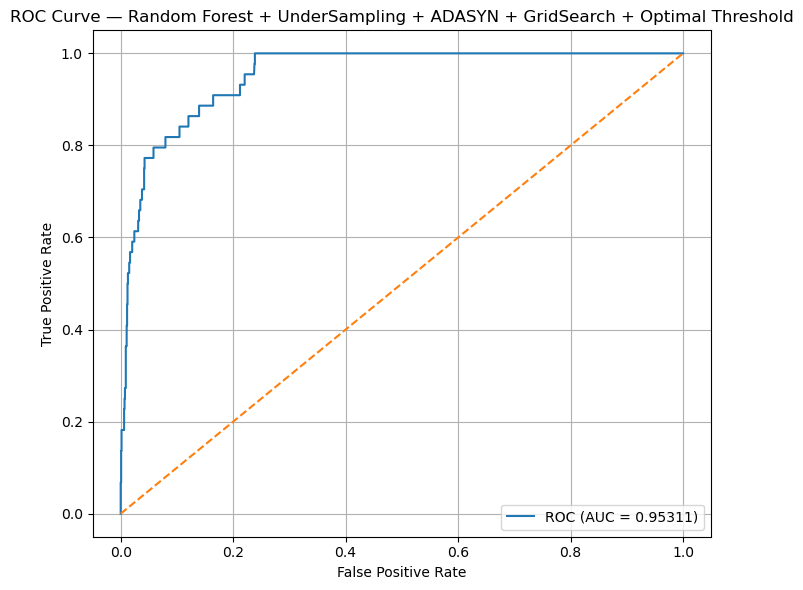

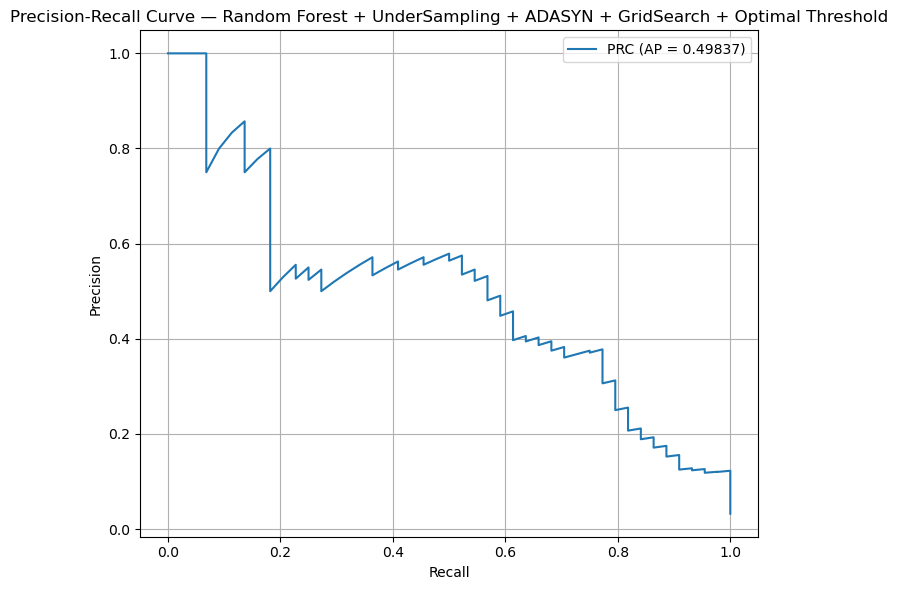

ROC AUC: 0.95311
PRC AUC: 0.49837


In [20]:
#Vytvorenie pipeline s undersamplingom, ADASYN a RF modelom
pipe2 = ImbPipeline(steps=[
    ("under", RandomUnderSampler(random_state=42)),
    ("adasyn", ADASYN(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

#Definovanie hyperparametrov pre GridSearch
param_grid = {
    "under__sampling_strategy": [0.05, 0.08],
    "adasyn__sampling_strategy": [0.25, 0.30],
    "adasyn__n_neighbors": [3],

    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nastavenie F1-score ako hodnotiacej metriky
scorer = make_scorer(f1_score, pos_label=1)

# Vytvorenie GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe2,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

# Trénovanie modelu a hľadanie najlepších parametrov
grid_search.fit(X_train, y_train)

# Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)

# Výpis najlepšieho F1-score z krížovej validácie
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

# Uloženie najlepšieho modelu
best_model5 = grid_search.best_estimator_

# Výpočet pravdepodobností pre triedu 1
y_proba5 = best_model5.predict_proba(X_test)[:, 1]

# Výpočet hodnôt pre Precision-Recall krivku
precisions5, recalls5, thresholds5 = precision_recall_curve(y_test, y_proba5)

# Výpočet F1-score pre rôzne prahy
f1_scores5 = 2 * (precisions5[:-1] * recalls5[:-1]) / (
    precisions5[:-1] + recalls5[:-1] + 1e-10
)

# Výber najlepšieho prahu podľa F1-score
best_threshold5 = thresholds5[np.argmax(f1_scores5)]
print(f"Best threshold: {best_threshold5:.4f}")
print(f"Best F1 from PR curve: {np.max(f1_scores5):.4f}")

# Predikcia tried podľa optimálneho prahu
y_pred5 = (y_proba5 >= best_threshold5).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (Random Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred5, digits=5))

roc_auc5 = roc_auc_score(y_test, y_proba5)
prc_auc5 = average_precision_score(y_test, y_proba5)

#Matica zámen
cm5 = confusion_matrix(y_test, y_pred5)
print("\nConfusion Matrix")
print(cm5)

ConfusionMatrixDisplay(cm5).plot()
plt.title("Confusion Matrix — Random Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
fpr5, tpr5, _ = roc_curve(y_test, y_proba5)

plt.figure(figsize=(7, 6))
plt.plot(fpr5, tpr5, label=f"ROC (AUC = {roc_auc5:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
plt.figure(figsize=(7, 6))
plt.plot(recalls5, precisions5, label=f"PRC (AP = {prc_auc5:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc5:.5f}")
print(f"PRC AUC: {prc_auc5:.5f}")

### Výsledky všetkých modelov ###

In [22]:
print("Baseline Random Forest")
print(classification_report(y_test, y_pred1))

print("\nBaseline Random Forest + SMOTE")
print(classification_report(y_test, y_pred2))

print("\nBaseline Random Forest + ADASYN")
print(classification_report(y_test, y_pred3))

print("\nRandom Forest + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred4))

print("\nRandom Forest + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred5))

Baseline Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.77      0.23      0.35        44

    accuracy                           0.97      1364
   macro avg       0.87      0.61      0.67      1364
weighted avg       0.97      0.97      0.97      1364


Baseline Random Forest + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.45      0.57      0.50        44

    accuracy                           0.96      1364
   macro avg       0.72      0.77      0.74      1364
weighted avg       0.97      0.96      0.97      1364


Baseline Random Forest + ADASYN
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.44      0.59      0.50        44

    accuracy                           0.96      1364
   macro avg       0.71      0.78      0

### Permutation importance ###

Top 10 Feature Importance (Permutation Importance)
                                              feature  importance_mean  \
35                         Total debt/Total net worth         0.059091   
7                         After-tax net Interest Rate         0.027273   
0    ROA(C) before interest and depreciation befor...         0.022727   
18            Persistent EPS in the Last Four Seasons         0.022727   
17                            Net Value Per Share (C)         0.022727   
15                            Net Value Per Share (B)         0.022727   
36                                       Debt ratio %         0.022727   
29                              Net Value Growth Rate         0.018182   
6                           Pre-tax net Interest Rate         0.018182   
51                        Operating profit per person         0.018182   

    importance_std  
35        0.011134  
7         0.017008  
0         0.000000  
18        0.000000  
17        0.000000  
15      

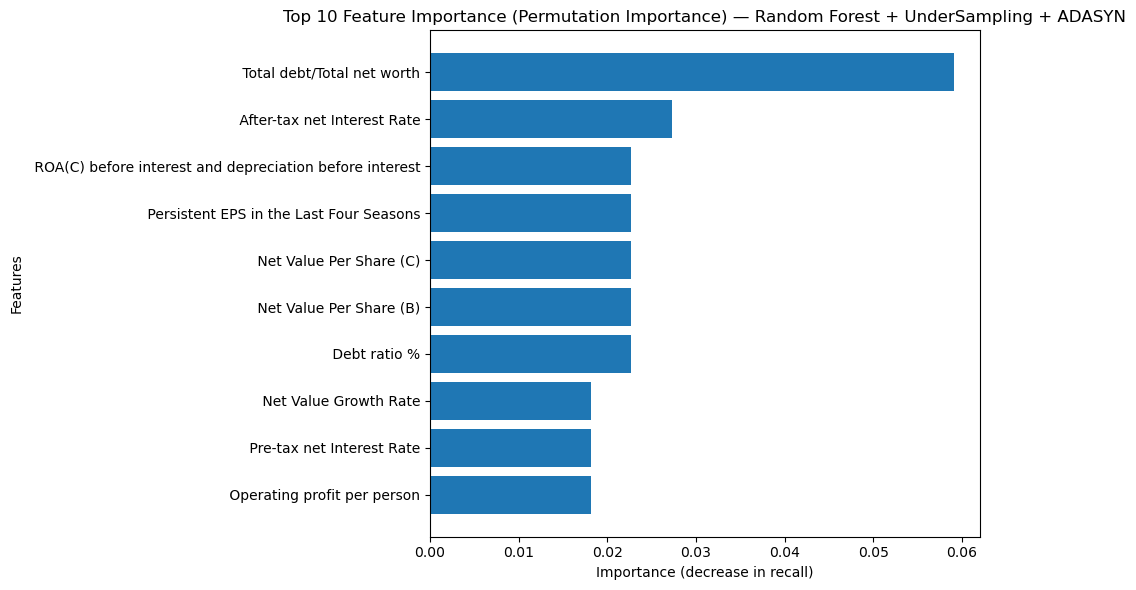

In [24]:
#Vytvorenie kópie testovacích dát
X_test_imp = X_test.copy()

#Výpočet permutation importance pre najlepší model
result = permutation_importance(
    estimator=best_model5,
    X=X_test_imp,
    y=y_test,
    scoring="recall",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

#Vytvorenie tabuľky s dôležitosťou premenných
importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

#Výpis 10 najdôležitejších premenných
print("Top 10 Feature Importance (Permutation Importance)")
print(importance_df.head(10))

#Výber 10 najdôležitejších premenných
top10 = importance_df.head(10)

#Vykreslenie grafu dôležitosti premenných
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Importance (decrease in recall)")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance (Permutation Importance) — Random Forest + UnderSampling + ADASYN")
plt.tight_layout()
plt.show()

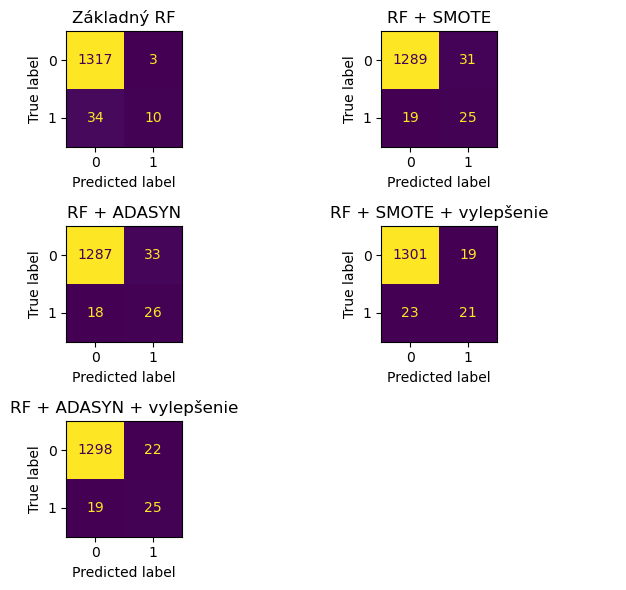

In [37]:
cms = [cm1, cm2, cm3, cm4, cm5]
titles = [
    "Základný RF",
    "RF + SMOTE",
    "RF + ADASYN",
    "RF + SMOTE + vylepšenie",
    "RF + ADASYN + vylepšenie"
]

fig, axes = plt.subplots(3, 2, figsize=(7, 6))
axes = axes.flatten()

for i in range(5):
    disp = ConfusionMatrixDisplay(cms[i])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(titles[i])

axes[5].axis('off')

plt.tight_layout()
plt.show()

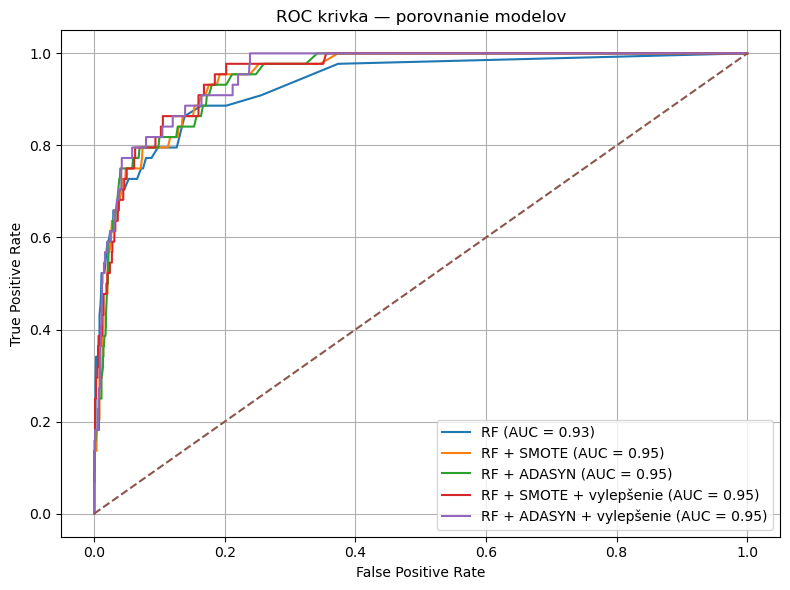

In [48]:
plt.figure(figsize=(8, 6))

plt.plot(fpr1, tpr1, label=f"RF (AUC = {roc_auc1:.2f})")
plt.plot(fpr2, tpr2, label=f"RF + SMOTE (AUC = {roc_auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"RF + ADASYN (AUC = {roc_auc3:.2f})")
plt.plot(fpr4, tpr4, label=f"RF + SMOTE + vylepšenie (AUC = {roc_auc4:.2f})")
plt.plot(fpr5, tpr5, label=f"RF + ADASYN + vylepšenie (AUC = {roc_auc5:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka — porovnanie modelov")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

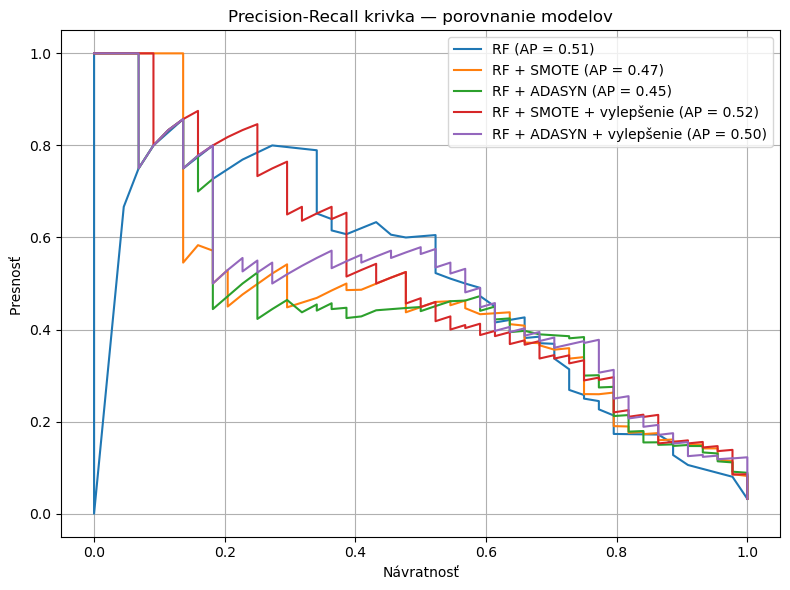

In [50]:
plt.figure(figsize=(8, 6))

plt.plot(recalls1, precisions1, label=f"RF (AP = {prc_auc1:.2f})")
plt.plot(recalls2, precisions2, label=f"RF + SMOTE (AP = {prc_auc2:.2f})")
plt.plot(recalls3, precisions3, label=f"RF + ADASYN (AP = {prc_auc3:.2f})")
plt.plot(recalls4, precisions4, label=f"RF + SMOTE + vylepšenie (AP = {prc_auc4:.2f})")
plt.plot(recalls5, precisions5, label=f"RF + ADASYN + vylepšenie (AP = {prc_auc5:.2f})")

plt.xlabel("Návratnosť")
plt.ylabel("Presnosť ")
plt.title("Precision-Recall krivka — porovnanie modelov")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()